In [98]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from swmm_api import SwmmInput, swmm5_run, SwmmReport
from swmm_api.input_file.section_labels import *
from swmm_api.input_file.sections import *
from datetime import datetime, timedelta
from scipy.optimize import brentq

In [86]:
def _shape_function(t, peak):
    return (1 - t) * np.exp(-(np.log(t+1e-3) - peak)**2)

def _max_intensity_for_peak(peak, duration, total_depth):
    dt_hr = 15 / 60
    T = np.arange(0, duration, dt_hr)
    t = T / duration

    shape = _shape_function(t, peak)
    shape /= np.trapz(shape, t)

    # convert shape to intensities (mm/hr)
    intensity = shape * (total_depth / len(T))

    return np.max(intensity)

def generate_hyetograph_15m(max_intensity, duration, total_depth, graph=False):
    # max_intensity: mm/hr
    max_intensity /= 4  # force the 15m rainfall not to exceed the average intensity of the hour

    def objective(peak):
        return _max_intensity_for_peak(peak, duration, total_depth) - max_intensity

    try:
        peak_solution = brentq(objective, -8, 0)
    except ValueError:
        raise ValueError("\nIt is impossible to accumulate the required rain depth with the given peak intensity following a bound lognormal curve.\n\nTry increasing the duration of the hyetograph or changing the maximum intensity.")

    dt_hr = 15 / 60
    T = np.arange(0, duration, dt_hr)
    t = T / duration
    t[0] = 1e-6

    shape = _shape_function(t, peak_solution)
    shape /= np.trapz(shape, t)

    # rainfall per interval (mm per 15 minutes)
    hyetograph = shape * total_depth / len(T)

    # cumulative depths
    depths = np.cumsum(hyetograph)

    data = list(zip(T, depths))

    gage = RainGage(
        name='RG',
        form='CUMULATIVE',
        interval='0:15:00',
        source='TIMESERIES',
        timeseries='TS',
        SCF=1.0,
        units='MM'
    )

    timeseries = TimeseriesData(
        name='TS',
        data=data
    )

    if graph:
        plt.figure(figsize=(10, 4))
        plt.bar(
            T,
            hyetograph,
            width=dt_hr,
            align='edge',
            alpha=0.8,
            edgecolor="black",
            linewidth=0.5,
            label=f"Rain Accumulated: {total_depth:.0f} mm\nPeak Rainfall: {max_intensity*4:.0f} mm/hr\nDuration: {duration} hours"
        )
        plt.xlabel("Time (hours)")
        plt.ylabel("Rainfall (mm per 15 min)")
        plt.title(f"Generated Hyetograph ")
        plt.grid(axis="y", linestyle="--", alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()


    return gage, timeseries


# Build Model

In [3]:
nodes = gpd.read_file('nodes.geojson')
edges = gpd.read_file('edges.geojson')
subcatchments = gpd.read_file('subcatchments.geojson')

In [4]:
nodes['SWMM_ID'] = [f"JN_{i}" if t == 'junction' else f"OF_{i}" if t=='outfall' else f"IN_{i}" for i, t in enumerate(nodes['node_type'])]
subcatchments['SWMM_ID'] = [f"SUB_{i}" for i in range(len(subcatchments))]
edges['SWMM_ID'] = [f"CON_{i}" for i in range(len(edges))]

node_to_id = {row.node_id: row.SWMM_ID for _, row in nodes.iterrows()}

In [5]:
inp = SwmmInput()

inp[OPTIONS] = OptionSection(
    FLOW_UNITS='CMS',
    INFILTRATION='GREEN_AMPT',
    FLOW_ROUTING='DYNWAVE',
    START_DATE='01/01/2025',
    START_TIME='00:00:00',
    END_DATE='01/02/2025',
    END_TIME='00:00:00',
)

max_intensity $\times$ duration > 2 $\cdot$ total_volume

(mm/hr) * (hr) > mm

In [6]:
inp[RAINGAGES]['RG'], inp[TIMESERIES]['TS'] = generate_hyetograph_15m(2, 24, 20)

for i, row in subcatchments.iterrows():
    area = row.geometry.area
    width = area ** 0.5
    area /= 10_000 # m^2 to hectares
    inp[SUBCATCHMENTS][row.SWMM_ID] = SubCatchment(
        name=row.SWMM_ID,
        rain_gage='RG',
        outlet=node_to_id[row.node_id],
        area=area,
        width=width,
        slope=row.slope,
        imperviousness=row.pct_impervious
    )

    inp[INFILTRATION][row.SWMM_ID] = InfiltrationGreenAmpt(
        subcatchment=row.SWMM_ID,
        suction_head=row['Suction'], # (mm)
        hydraulic_conductivity=row['Ksat'], # (mm/hr)
        moisture_deficit_init=row['IMD']
    )

    # default runoff parameters
    inp[SUBAREAS][row.SWMM_ID] = SubArea(
        subcatchment=row.SWMM_ID,
        n_imperv=0.015,
        n_perv=0.15,
        storage_imperv=2.0, # (mm)
        storage_perv=5.0, # (mm)
        pct_zero=25.0
    )

In [7]:
for i, row in nodes.iterrows():
    if row['node_type'] == 'outfall':
        inp[OUTFALLS][row.SWMM_ID] = Outfall(
            name=row.SWMM_ID,
            elevation=row['invert_elevation'],
            kind = 'FREE'
        )
    else:
        inp[JUNCTIONS][row.SWMM_ID] = (Junction(
            name=row.SWMM_ID,
            elevation=row['invert_elevation']
        ))

In [8]:
for i, row in edges.iterrows():
    inp[CONDUITS][row.SWMM_ID] = Conduit(
        name=row.SWMM_ID,
        from_node=node_to_id[row.start_node],
        to_node=node_to_id[row.end_node],
        length=row.geometry.length,
        roughness=0.013, # Manning's n, mostly RCP AND PVC Pipes.
    )

    inp[XSECTIONS][row.SWMM_ID] = CrossSection(
        link=row.SWMM_ID,
        shape='CIRCULAR',
        height=row['diameter']
    )

In [9]:
inp.to_file('watershed_model.inp')

'watershed_model.inp'

# Run Model Under Specific Conditions

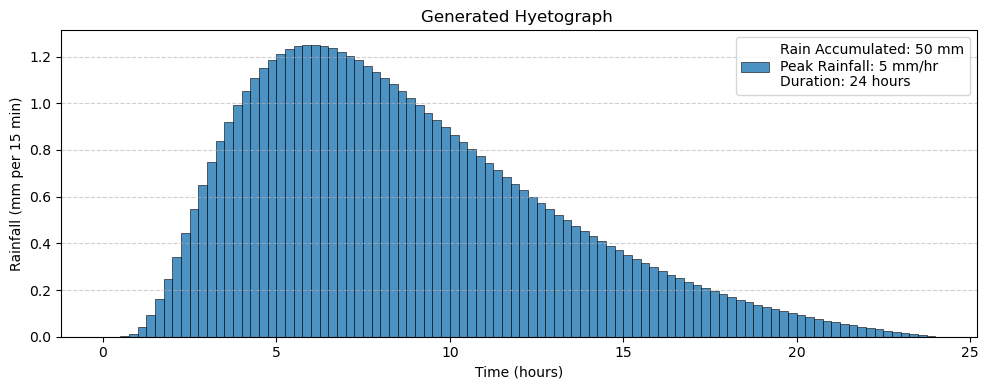

'watershed_model.inp'

In [96]:
inp = SwmmInput('watershed_model.inp')
peak_flow = 5 # mm/hr
duration = 24 # hr
total_volume = 50 # mm

inp[OPTIONS]['START_DATE'] = '01/01/2025'
inp[OPTIONS]['START_TIME'] = '00:00:00'
start_time = datetime.strptime(f"{inp[OPTIONS]['START_DATE']} {inp[OPTIONS]['START_TIME']}", '%m/%d/%Y %H:%M:%S')
end_time = start_time + timedelta(hours=duration+3)
inp[OPTIONS]['END_DATE'] = end_time.strftime('%m/%d/%Y')
inp[OPTIONS]['END_TIME'] = end_time.strftime('%H:%M:%S')

inp[RAINGAGES]['RG'], inp[TIMESERIES]['TS'] = generate_hyetograph_15m(peak_flow, duration, total_volume, graph=True)
inp.to_file('watershed_model.inp')

In [97]:
swmm5_run('watershed_model.inp', progress_size=100)

swmm5 watershed_model.inp: 100%|██████████| 100/100 [02:47<00:00,  1.67s/it, 2025-01-02 03:00:00]


In [108]:
rpt = SwmmReport('watershed_model.rpt')

In [109]:
watershed = gpd.read_file('GIS/WATERSHEDS_CLIPPED.geojson')
watershed = watershed[watershed.NAME == "Popes Head Creek"].to_crs(subcatchments.crs)

sump = gpd.read_file('GIS/SUMP.geojson')
sump = sump.to_crs(watershed.crs).clip(watershed.geometry)
floodplain = gpd.read_file('GIS/FLOODPLAIN.geojson')
floodplain = floodplain.to_crs(watershed.crs).clip(watershed.geometry)

In [110]:
subcatchments['pct_sump'] = subcatchments.geometry.apply(lambda x: round(sump.clip(x).area.sum() / x.area * 100, 3))
subcatchments['near_floodplain'] = subcatchments.geometry.apply(lambda x: floodplain.clip(x).area.sum() > 0)

In [111]:
runoff = gpd.GeoDataFrame(rpt.subcatchment_runoff_summary, geometry=subcatchments.set_index('SWMM_ID').geometry)

In [112]:
runoff['runoff_per_ha'] = runoff['Total_Runoff_10^6 ltr'] * 1000 / (runoff.geometry.area / 10_000) # m^3 per ha

<Axes: >

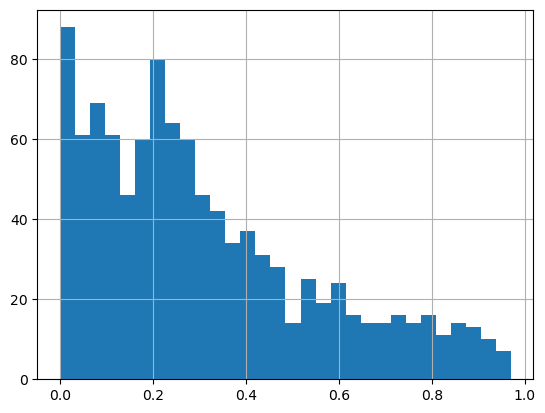

In [113]:
runoff.Runoff_Coeff.hist(bins=30)

In [114]:
runoff['pct_sump'] = subcatchments.set_index('SWMM_ID').pct_sump / 100
runoff['near_floodplain'] = subcatchments.set_index('SWMM_ID').near_floodplain

<Axes: >

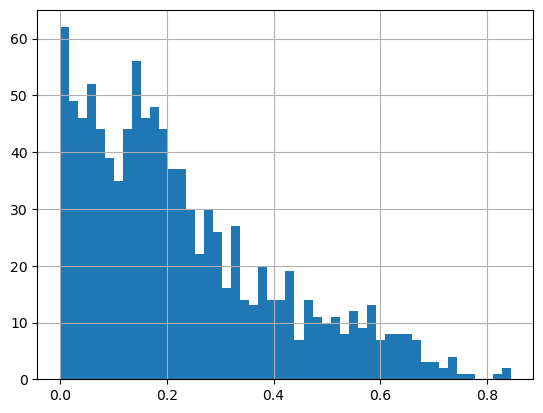

In [115]:
a = 0.3
b = 0.1
runoff['flood_risk'] = runoff['Runoff_Coeff'] * (1 + a * runoff['pct_sump'] + b * runoff.near_floodplain) / (1 + a + b)
runoff['flood_risk'].hist(bins=50)

In [176]:
import pandas as pd

In [177]:
flood_grid = gpd.read_file('GIS/FLOOD_GRID.geojson').clip(watershed.geometry)

joined = gpd.overlay(flood_grid, runoff, how='intersection')
joined['area'] = joined.geometry.area
grouped = joined.groupby('grid_id').apply(lambda df: pd.Series({'flood_risk': (df['area'] * df['flood_risk']).sum() / df['area'].sum()}))

/tmp/ipykernel_26579/1459202608.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = joined.groupby('grid_id').apply(lambda df: pd.Series({'flood_risk': (df['area'] * df['flood_risk']).sum() / df['area'].sum()}))


In [178]:
flood_grid = flood_grid.merge(grouped, left_on='grid_id', right_index=True)

<Axes: >

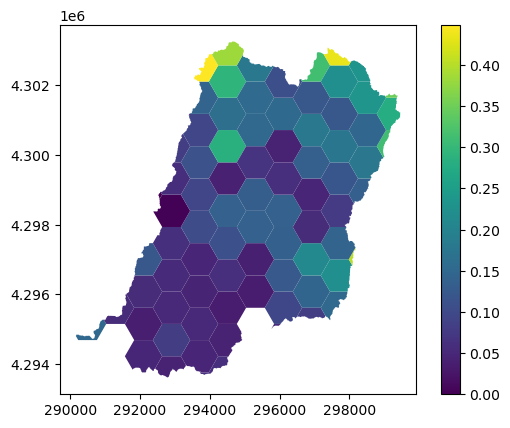

In [179]:
flood_grid.plot(column='flood_risk', legend=True)

<Axes: >

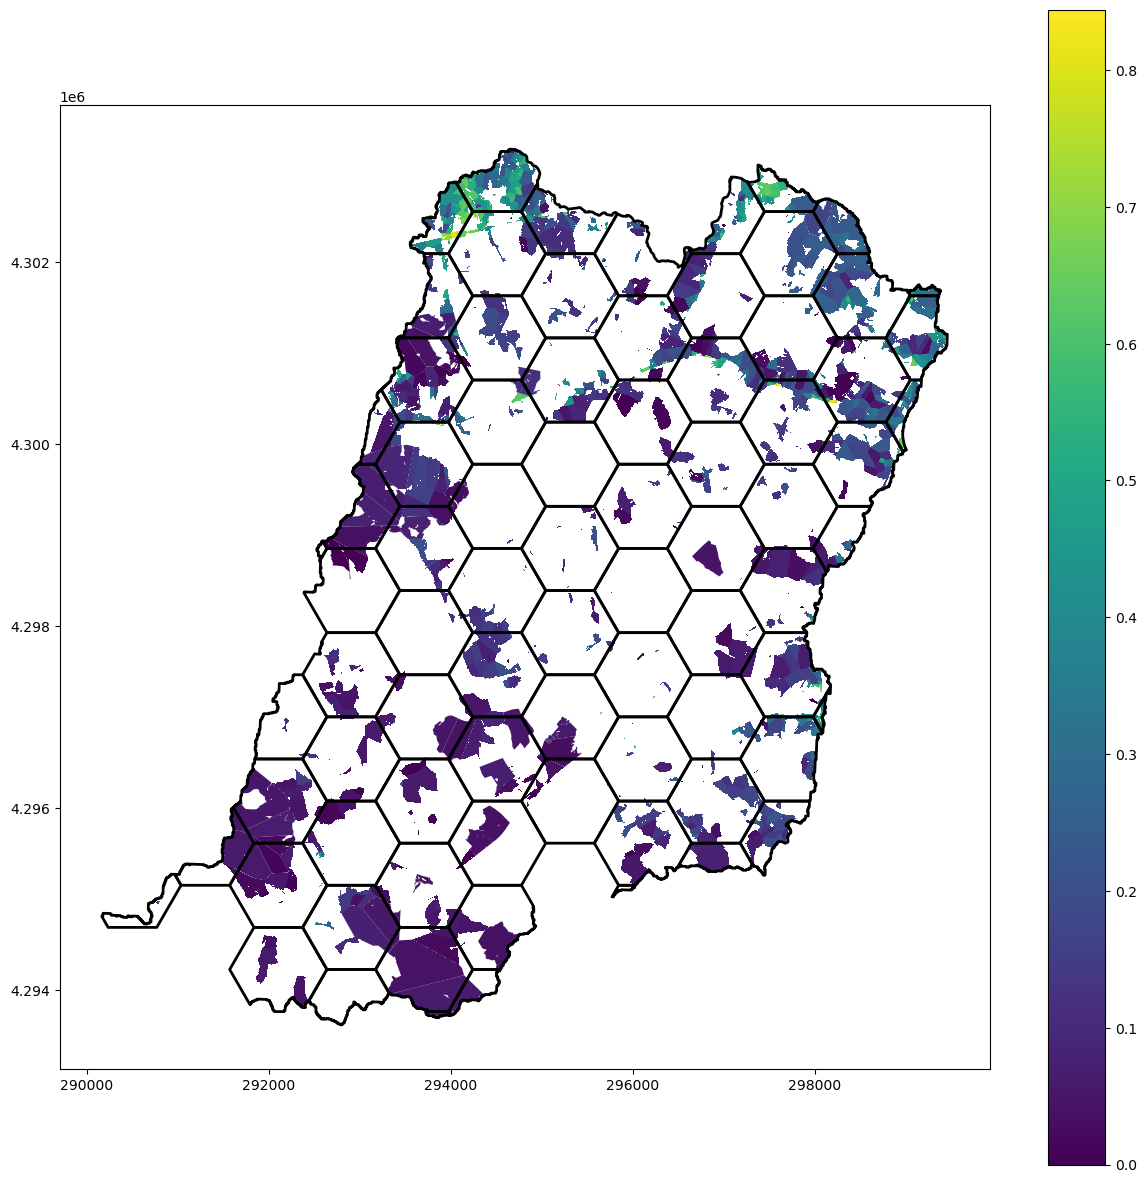

In [180]:
fig, ax = plt.subplots(figsize=(15, 15))
runoff.plot(ax=ax, column='flood_risk', legend=True)
flood_grid.plot(ax=ax, color='none', edgecolor='k', linewidth=2)
# gpd.GeoDataFrame(rpt.node_flooding_summary, geometry=nodes.set_index('SWMM_ID').geometry).plot(ax=ax, column='Total_Flood_Volume_10^6 ltr', legend=True)
# sump.clip(subcatchments).plot(ax=ax, color='none', edgecolor='k', linewidth=2)
# floodplain.clip(subcatchments).plot(ax=ax, color='none', edgecolor='red', linewidth=2)